In [1]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from collections import deque

import seaborn as sns
import matplotlib.pyplot as plt
from structure_learning.approximators import StructureMCMC
from structure_learning.data import SyntheticDataset, Data
from structure_learning.distributions import Distribution, OPAD
from structure_learning.data_structures import DAG
from structure_learning.scores import BGeScore

np.random.seed(100)

In [3]:
class SEM_Synthetic_Data(object):
    """
    Generate standardised synthetic data from graphs.
    """
    def __init__(
        self,
        num_nodes: int,
        num_obs: int,
        node_labels: list,
        degree: float,
        graph_type: str = "erdos-renyi",
        noise_scale: float = 1.0,
        true_dag = None):
        """
        Initialise SyntheticDataset instance
        """
        self.num_nodes = num_nodes
        self.num_obs = num_obs
        self.node_labels = node_labels
        self.degree = degree
        self.graph_type = graph_type
        self.noise_scale = noise_scale
        self.w_range = (0.5, 2.5)
        self.true_dag = true_dag

        self._setup()

    def _setup(self):
        """
        Initial setup. Simulates random dag (if not given) and data.
        """
        self.W, _, self.P = self.simulate_random_dag(
            self.num_nodes,
            self.degree,
            self.graph_type,
            self.w_range
        )

        if self.true_dag is None:
            self.data = pd.DataFrame(self.simulate_data(
                self.W,
                self.num_obs
            ), columns=self.node_labels)
        else:
            self.data, self.W = self.simulate_data_from_dag(
                self.true_dag,
                self.num_obs,
                self.num_nodes,
                self.node_labels,
                self.w_range,
                self.noise_scale
            )

        self.adj_mat = pd.DataFrame(np.where(self.W != 0, 1, 0), columns=self.node_labels)
        self.graph = DAG(self.adj_mat)
        self.data = Data(self.data, self.node_labels)



    @staticmethod
    def simulate_random_dag(d, degree, graph_type, w_range):
        """Simulate random DAG with some expected degree.
        Parameters:
            d (int): number of nodes
            degree (int): expected node degree, in + out
            graph_type (str): {erdos-renyi, barabasi-albert, full}
            w_range (2-tuple (float)): weight range +/- (low, high)
        Returns:
            (numpy.ndarray): weighted DAG
            None
            (numpy.ndarray): permutation matrix
        """
        if graph_type == "erdos-renyi":
            prob = float(degree) / (d - 1)
            B = np.tril((np.random.rand(d, d) < prob).astype(float), k=-1)
        elif graph_type == "barabasi-albert":
            m = int(round(degree / 2))
            B = np.zeros([d, d])
            bag = [0]
            for ii in range(1, d):
                dest = np.random.choice(bag, size=m)
                for jj in dest:
                    B[ii, jj] = 1
                bag.append(ii)
                bag.extend(dest)
        elif graph_type == "full":  # ignore degree, only for experimental use
            B = np.tril(np.ones([d, d]), k=-1)
        else:
            raise ValueError("Unknown graph type")
        # random permutation
        P = np.random.permutation(np.eye(d, d))  # permutes first axis only
        B_perm = P.T.dot(B).dot(P)
        U = np.random.uniform(low=w_range[0], high=w_range[1], size=[d, d])
        U[np.random.rand(d, d) < 0.5] *= -1
        W = (B_perm != 0).astype(float) * U

        # At the moment the generative process is P.T @ lower @ P, we want
        # it to be P' @ upper @ P'.T.
        # We can return W.T, so we are saying W.T = P'.T @ lower @ P.
        # We can then return P.T, as we have
        # (P.T).T @ lower @ P.T = W.T

        return W.T, None, P.T

    @staticmethod
    def topological_sort(adj_matrix):
        """
        Sort the random dag that has been generated topologically.
        i.e. Source Nodes first and absorbing nodes last
        """
        num_nodes = adj_matrix.shape[0]
        in_degree = np.zeros(num_nodes, dtype=int)
        for i in range(num_nodes):
            for j in range(num_nodes):
                if adj_matrix[i, j] != 0:
                    in_degree[j] += 1

        queue = deque([i for i in range(num_nodes) if in_degree[i] == 0])
        top_order = []

        while queue:
            node = queue.popleft()
            top_order.append(node)
            for j in range(num_nodes):
                if adj_matrix[node, j] != 0:
                    in_degree[j] -= 1
                    if in_degree[j] == 0:
                        queue.append(j)

        return top_order

    @staticmethod
    def simulate_data(adj_matrix, num_obs, noise_variance=1.0):
        """Simulate data from the weighted DAG."""
        num_nodes = adj_matrix.shape[0]
        data = np.zeros((num_obs, num_nodes))

        # Get topological order of nodes
        top_order = SEM_Synthetic_Data.topological_sort(adj_matrix)

        for node in top_order:
            parents = [i for i in range(num_nodes) if adj_matrix[i, node] != 0]


            noise = np.random.normal(
                loc=0.0,
                scale=np.sqrt(noise_variance),
                size=num_obs,
            )

            if not parents:
                # If no parents, generate data independently
                data[:, node] = noise
            else:
                # Manually extract and combine parent columns
                parent_values_list = []
                #for parent in parents:
                    # Extract Parent Values
                    #parent_values = data[:, parent].reshape(-1, 1)
                    # Standardising each parent node
                    #parent_values_standardised = (parent_values - np.mean(parent_values)) / np.std(parent_values)
                    # Append to list
                    #parent_values_list.append(parent_values_standardised)

                # Combine all parent columns into a single array
                #parent_values_combined = np.hstack(parent_values_list)

                # Generate data based on weighted sum of parent values + noise
                weights = adj_matrix[parents, node]
                print(f"Node {node} has parents {parents} with weights {weights}")
                data[:, node] = np.dot(data[:, parents], weights) + noise

        return data



In [4]:
#synthetic_data = SEM_Synthetic_Data(num_nodes=5, num_obs=5000, node_labels=[chr(ord('a') + i) for i in range(5)], degree=2)
synthetic_data = SyntheticDataset(num_nodes=5, num_obs=500, node_labels=[chr(ord('a') + i) for i in range(5)], degree=2)


00010 00100 10000 00000 01010


In [5]:
synthetic_data.W.weights

array([[-0.        ,  0.        , -0.        , -0.73660567,  0.        ],
       [-0.        ,  0.        , -1.26214681,  0.        , -0.        ],
       [ 1.66277792, -0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.        ,  0.        , -0.        ],
       [ 0.        , -2.05201063,  0.        ,  2.17226363,  0.        ]])

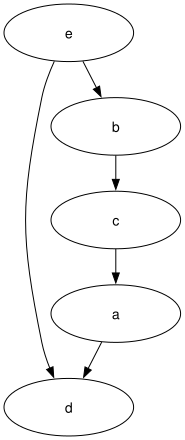

In [6]:
synthetic_data.graph.plot()

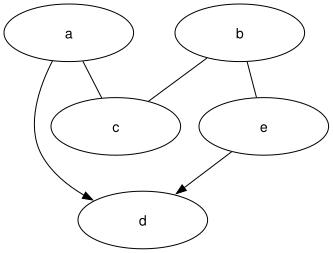

In [7]:
synthetic_data.graph.to_cpdag().plot()


In [8]:
from test_bge import BGeScore
from sklearn.preprocessing import StandardScaler


In [9]:

scaled_data = synthetic_data.data.standardise()
scaled_data.sds

{'a': 5.276386024817595,
 'b': 2.333118157672746,
 'c': 3.1070910094183954,
 'd': 2.5055886882745866,
 'e': 1.0023100391041948}

In [10]:
scaled_data.mus

{'a': 0.1632031076053676,
 'b': -0.061576315532466806,
 'c': 0.08515350396414799,
 'd': -0.12055508859945363,
 'e': 0.011243591575457356}

In [11]:
score_struct = BGeScore(scaled_data)

In [12]:
scaled_data.values.loc

In [13]:
score_struct._muN

a    1.152327e-17
b    1.772811e-18
c   -5.318434e-18
d   -5.318434e-17
e   -3.722904e-17
dtype: float64

In [14]:
score_res = score_struct.compute(synthetic_data.graph, compute_full_posterior=True)

C:\Users\161342\code\structure_learning\examples\test_bge.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "muN_node": self._muN[node_indx],
C:\Users\161342\code\structure_learning\examples\test_bge.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "muN_parents": self._muN[parentnodes],
C:\Users\161342\code\structure_learning\examples\test_bge.py:156: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "muN_node": self._muN[node_

In [15]:
score_res['parameters']['a']

{'score': np.float64(109.62428451546329),
 'node_idx': 0,
 'parents': [2],
 'node_label': 'a',
 'parent_label': [np.str_('c')],
 'posterior': {'sigma2_shape': 252.0,
  'sigma2_scale': np.float64(9.269759159570668),
  'muN_node': np.float64(1.1523272910281065e-17),
  'muN_parents': c   -5.318434e-18
  dtype: float64,
  'beta_mean': array([0.98126645]),
  'chol_parent_T': array([[22.34949664]]),
  'kappa_N': 501.0}}

In [16]:
score_struct.posterior_mode('a', node_parameters=score_res['parameters']['a'])

{'beta': array([0.98126645]),
 'sigma2': np.float64(0.03663936426707774),
 'intercept': np.float64(1.6742073422018307e-17)}

In [17]:
score_struct.node_marginal_likelihood(score_res['parameters']['a']['posterior'])

np.float64(109.62428451546329)

In [18]:
np.asarray(list(scaled_data.sds.values()))[:, None]

array([[5.27638602],
       [2.33311816],
       [3.10709101],
       [2.50558869],
       [1.00231004]])

In [19]:
true_beta = synthetic_data.W.weights
scaled_beta = true_beta * np.asarray(list(scaled_data.sds.values()))[:, None] / np.asarray(list(scaled_data.sds.values()))[None, :]

scaled_beta

array([[-0.        ,  0.        , -0.        , -1.55117873,  0.        ],
       [-0.        ,  0.        , -0.94774747,  0.        , -0.        ],
       [ 0.97915549, -0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.        ,  0.        , -0.        ],
       [ 0.        , -0.88154595,  0.        ,  0.86897009,  0.        ]])

In [20]:
true_sigma2 = (synthetic_data.noise_std**2)
scale_sigma2 = true_sigma2 / (np.asarray(list(scaled_data.sds.values()))**2)
scale_sigma2

array([0.03591922, 0.18370735, 0.10358385, 0.15928704, 0.99539588])

In [33]:
scaled_data.sds

{'a': 5.276386024817595,
 'b': 2.333118157672746,
 'c': 3.1070910094183954,
 'd': 2.5055886882745866,
 'e': 1.0023100391041948}

C:\Users\161342\code\structure_learning\examples\test_bge.py:603: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  muP = self._muN[parent_idx]
C:\Users\161342\code\structure_learning\examples\test_bge.py:607: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self._muN[node_idx]


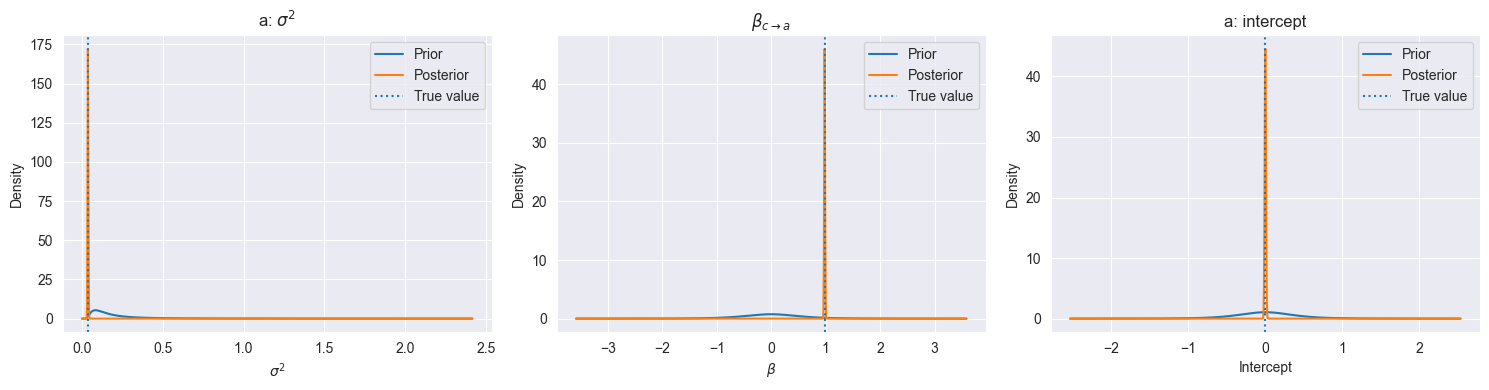

In [21]:
node2plot = 'a'
score_struct.plot_parameter_posterior(
            score_res['parameters'][node2plot],
            true_beta=scaled_beta[score_res['parameters'][node2plot]['parents'], score_res['parameters'][node2plot]['node_idx']],
            true_sigma2=scale_sigma2[score_res['parameters'][node2plot]['node_idx']],
            true_intercept=0.)

In [22]:
for node in score_struct.node_labels:
    true_beta = synthetic_data.W.weights[score_res['parameters'][node]['parents'], score_res['parameters'][node]['node_idx']]

In [42]:
# Sample y
y_ = score_struct.sample_y(score_res['parameters']['a'], scaled_data['c'])
y_.shape

(1, 500)

In [43]:
scaled_data.values

,a,b,c,d,e
0,-0.029805,0.093711,-0.093499,0.167058,-0.477427
1,0.028781,-0.400211,0.115927,-0.169076,0.046969
2,0.316493,0.482770,-0.113177,-0.313756,-0.191566
3,0.799090,-0.682195,0.611476,-1.175803,0.161754
4,0.296982,-0.251420,0.503408,-0.361298,0.533036
...,...,...,...,...,...
495,-0.417655,0.575983,-0.347991,0.597276,-0.396284
496,-2.268054,2.551754,-2.318359,2.037201,-2.115439
497,1.265809,-1.272192,1.304060,-0.972158,1.023824
498,-0.268012,0.578587,-0.351595,0.121434,-0.075388


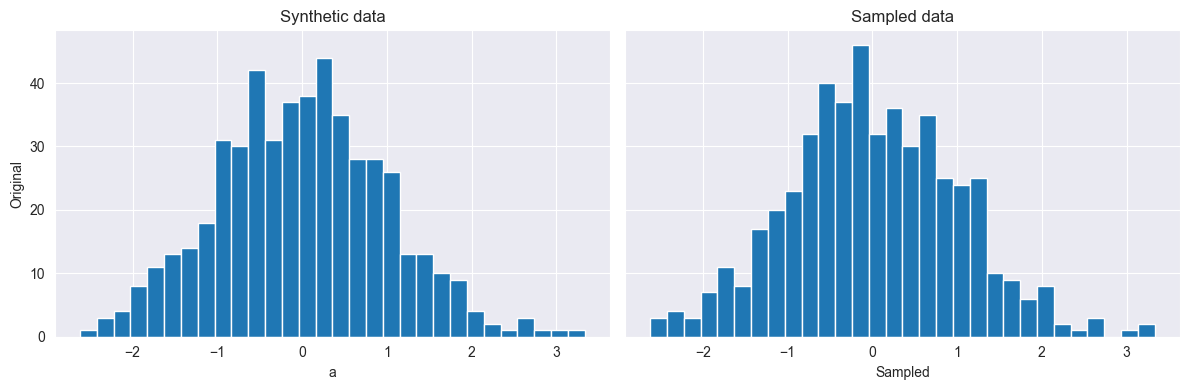

In [44]:
# Histogram of columns 'a' in the data
bins = np.histogram_bin_edges(
    np.concatenate([scaled_data['a'].values.flatten(), y_.flatten()]),
    bins=30
)


fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

ax[0].hist(scaled_data['a'].values.flatten(), bins=bins)
ax[0].set_title("Synthetic data")
ax[0].set_xlabel("a")
ax[0].set_ylabel("Original")

ax[1].hist(y_.flatten(), bins=bins)
ax[1].set_title("Sampled data")
ax[1].set_xlabel("Sampled")

plt.tight_layout()
plt.show()



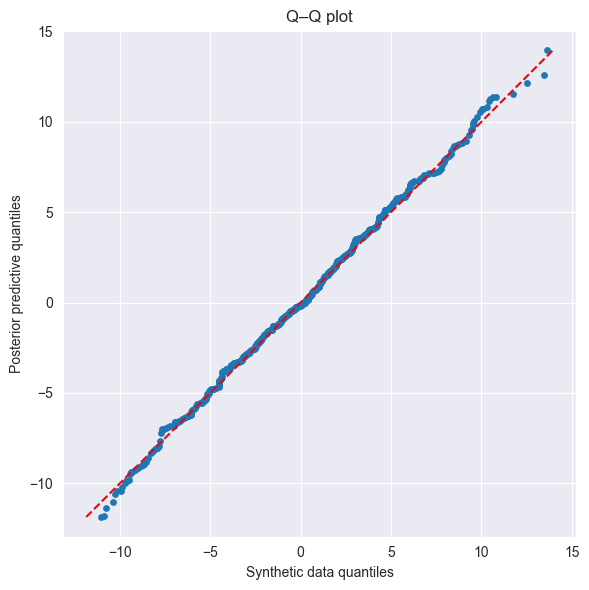

In [45]:
node2plot = 'a'
x_true = np.asarray(synthetic_data.data[node2plot].values.flatten())
x_sampled = np.asarray(y_).flatten()*scaled_data.sds[node2plot] + scaled_data.mus[node2plot]

# Common quantile levels
n = min(len(x_true), len(x_sampled))
q = np.linspace(0.01, 0.99, n)

q_true = np.quantile(x_true, q)
q_pred = np.quantile(x_sampled, q)

plt.figure(figsize=(6, 6))

plt.scatter(q_true, q_pred, s=15)

# y = x reference line
low = min(q_true.min(), q_pred.min())
high = max(q_true.max(), q_pred.max())

plt.plot(
    [low, high],
    [low, high],
    linestyle="--",
    color='r'
)

plt.xlabel("Synthetic data quantiles")
plt.ylabel("Posterior predictive quantiles")
plt.title("Q–Q plot")

plt.axis("equal")
plt.tight_layout()
plt.show()

1. Handling data standartidation following parameter estimation
2. Sequential bge calculation
